## Assignment 5 - Deadline: April 5, 2026, Sun 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [1]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
"""import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers"""
from IPython.display import HTML
from sklearn.model_selection import train_test_split

# Set the display option to show all rows scrolling with a slider
pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

You can use Tensorflow or PyTorch in this assignment.

# Problem 1: MNIST with shuffled pixels (50 pts)

In class (Lecture 08.ipynb), we loaded MNIST data from Keras, normalized it, trained it and reached >96% accuracy. Your task is now: <br>

**Part a)** For every image in the MNIST dataset, randomly shuffle its pixels with the same fixed shuffling function. To do this, generate a single random permutation of pixel positions and use it as a fixed shuffling function. Once defined, apply this function to all images in the dataset. Note: The shuffling function must remain the same for every image; all images should have their pixels rearranged using the exact same permutation. (If you shuffle each image with a random but different shuffling function, your dataset will be completely random and cannot be learned.)  <br>

**Part b)** Make a plot with MNISTplot2D(x_train[50]). The image should look like a noise, not as an image of a handwritten number since pixels are shuffled. <br>

**Part c)** Train an ANN model as we did in Lecture 08.ipynb, but use early stopping. You should have gotten the same accuracy again around 96%. Explain why the model's accuracy did not drop significantly, even though we completely destroyed the spatial structure in the images where neighboring pixels were correlated due to image smoothness.

In [2]:
# part a

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch import nn, optim
import copy

In [3]:
ROOT = '../datasets/MNIST/data'

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
torch.manual_seed(3407) # set random seed for reproducibility
fixed_perm = torch.randperm(28*28) # fixed random permutation of pixel indices

def shuffling_transform(image: torch.Tensor, perm=fixed_perm):
    # Convert PIL Image to PyTorch tensor
    # Shuffle the pixels using the fixed permutation
    shuffled_image = image.view(-1)[perm].view(1, 28, 28)
    return shuffled_image

def inverse_shuffling_transform(image: torch.Tensor, perm=fixed_perm):
    # Inverse the shuffling by applying the inverse permutation
    inverse_perm = torch.argsort(perm)
    unshuffled_image = image.view(-1)[inverse_perm].view(1, 28, 28)
    return unshuffled_image
    

transform = transforms.Compose([
    transforms.ToTensor(), # Convert PIL Image to PyTorch tensor
    transforms.Normalize((0.1307,), (0.3081,)), # Normalize with mean and standard deviation
    shuffling_transform # random shuffle the pixels in the image
])


# Load the MNIST dataset with the defined transform
train_dataset = torchvision.datasets.MNIST(root=ROOT, train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root=ROOT, train=False, download=True, transform=transform)
val_dataset, test_dataset = torch.utils.data.random_split(test_dataset, [5000, 5000], generator=torch.Generator().manual_seed(3407))

# Create data loaders for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



In [ ]:
# part b

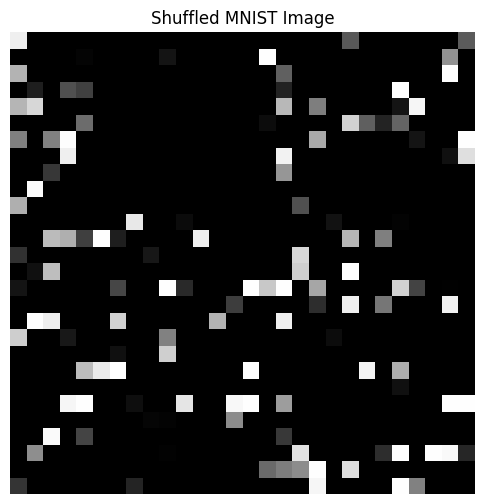

In [5]:
def MNISTplot2D(image):
    # Reshape the 1D tensor back to 28x28
    image_2d = image.view(28, 28)
    
    # Plot the image using seaborn heatmap
    plt.figure(figsize=(6, 6))
    sns.heatmap(image_2d.numpy(), cmap='gray', cbar=False, xticklabels=False, yticklabels=False)
    plt.title('Shuffled MNIST Image')
    plt.show()

# Get a sample image from the training dataset
sample_image, sample_label = train_dataset[50]  # Get the first image and its label
# Plot the sample image
MNISTplot2D(sample_image)

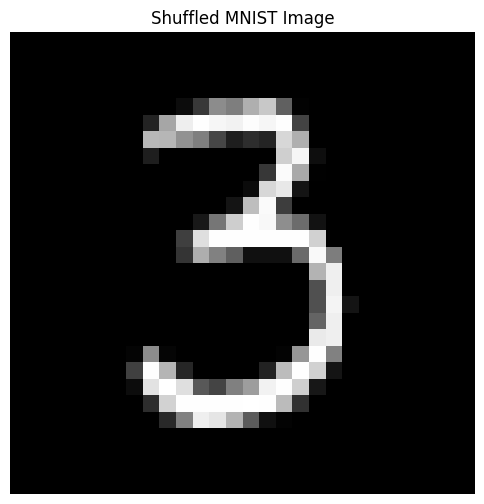

In [6]:
# Original Image Before Shuffling

sample_image_unshuffled = inverse_shuffling_transform(sample_image)
MNISTplot2D(sample_image_unshuffled)

In [ ]:
# part c

In [ ]:
class MnistClassifier(nn.Module):
    def __init__(self):
        super(MnistClassifier, self).__init__()
        self.dense1 = nn.Linear(28*28, 25)  # Input layer to hidden layer
        self.dense2 = nn.Linear(25, 25)
        self.output = nn.Linear(25, 10)     # Hidden layer to output layer
        
    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input image
        x = torch.relu(self.dense1(x))  # First hidden layer with ReLU activation
        x = torch.relu(self.dense2(x))  # Second hidden layer with ReLU activation
        x = self.output(x)  # Output layer (logits)
        return x 

In [67]:
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler=None, num_epochs=100):
    best_val_loss = float("inf")
    delta = 0.001
    best_model = copy.deepcopy(model.state_dict())
    last_improvement_epoch = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        run_epoch_train_loss = 0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits , y_batch)
            loss.backward()
            optimizer.step()
            run_epoch_train_loss += loss.item()

        avg_train_loss = run_epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}", end='')

        # Validation phase
        model.eval()
        run_epoch_val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device) # Reshape to (batch_size, 1)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                run_epoch_val_loss += loss.item()

        avg_val_loss = run_epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f", Validation Loss: {avg_val_loss:.4f}")
        
        if scheduler is not None:
            scheduler.step(avg_val_loss)

        # Early stopping based on validation loss
        if avg_val_loss < best_val_loss - delta:
            best_val_loss = avg_val_loss
            best_model = copy.deepcopy(model.state_dict())
            last_improvement_epoch = epoch
        elif epoch - last_improvement_epoch >= 15: # Stop if no improvement for 15 epochs
            print(f"Early stopping at epoch {epoch} with best validation loss: {best_val_loss:.4f}")
            break

    return train_losses, val_losses, best_val_loss, best_model, last_improvement_epoch

In [22]:
model = MnistClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, nesterov=True)

In [23]:
train_losses, val_losses, best_val_loss, best_model, last_improvement_epoch = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=100)

Epoch 1/100, Train Loss: 0.9466, Validation Loss: 0.3908
Epoch 2/100, Train Loss: 0.3565, Validation Loss: 0.2999
Epoch 3/100, Train Loss: 0.2961, Validation Loss: 0.2642
Epoch 4/100, Train Loss: 0.2605, Validation Loss: 0.2325
Epoch 5/100, Train Loss: 0.2343, Validation Loss: 0.2154
Epoch 6/100, Train Loss: 0.2135, Validation Loss: 0.1957
Epoch 7/100, Train Loss: 0.1962, Validation Loss: 0.1866
Epoch 8/100, Train Loss: 0.1827, Validation Loss: 0.1717
Epoch 9/100, Train Loss: 0.1711, Validation Loss: 0.1638
Epoch 10/100, Train Loss: 0.1613, Validation Loss: 0.1585
Epoch 11/100, Train Loss: 0.1525, Validation Loss: 0.1524
Epoch 12/100, Train Loss: 0.1454, Validation Loss: 0.1465
Epoch 13/100, Train Loss: 0.1396, Validation Loss: 0.1433
Epoch 14/100, Train Loss: 0.1333, Validation Loss: 0.1360
Epoch 15/100, Train Loss: 0.1279, Validation Loss: 0.1374
Epoch 16/100, Train Loss: 0.1231, Validation Loss: 0.1291
Epoch 17/100, Train Loss: 0.1189, Validation Loss: 0.1290
Epoch 18/100, Train Los

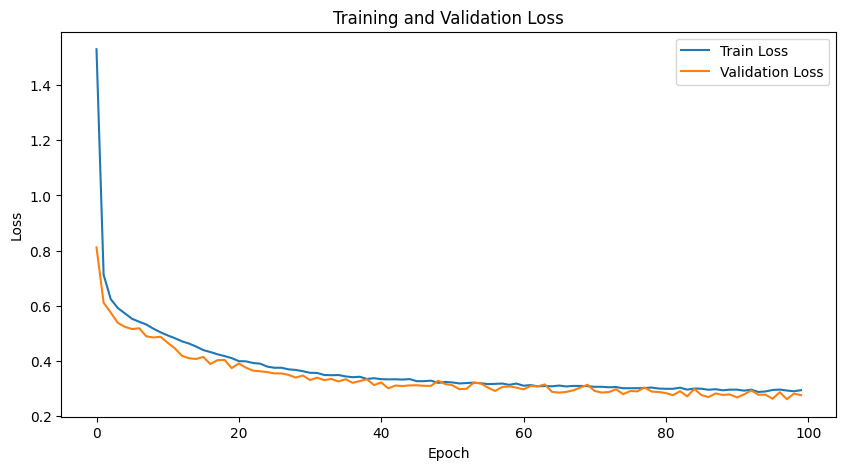

In [49]:
# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [25]:
model = MnistClassifier().to(device)
model.load_state_dict(best_model)
model.eval()


@torch.no_grad()
def evaluate_model(model, test_loader, criterion):
    test_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        test_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    accuracy = correct / total
    return avg_test_loss, accuracy

test_loss, test_accuracy = evaluate_model(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1174, Test Accuracy: 0.9652


# Problem 2: Noisy MNIST (50 pts)

**Part a)** Write a function that takes an MNIST image, randomly selects 50% of its pixels, and assigns a random integer between 0 and 255 to each of these pixels. Each selected pixel should receive its own random value (though some pixels may end up with the same value by chance). Apply this function to all dataset to obtain noisy MNIST dataset. Note that this function will apply a different noise on each image as the function will be choosing different pixels and assigns random numbers to them each time it is called.
Caution: Do this after loading the dataset `(x_train, y_train), (x_test, y_test) = mnist.load_data()` and before you normalize it. 

**Part b)** Run `MNISTplot2D(x_train[50])`. It should output noisy "3" as below, where the handwritten number is still discernable by eye.

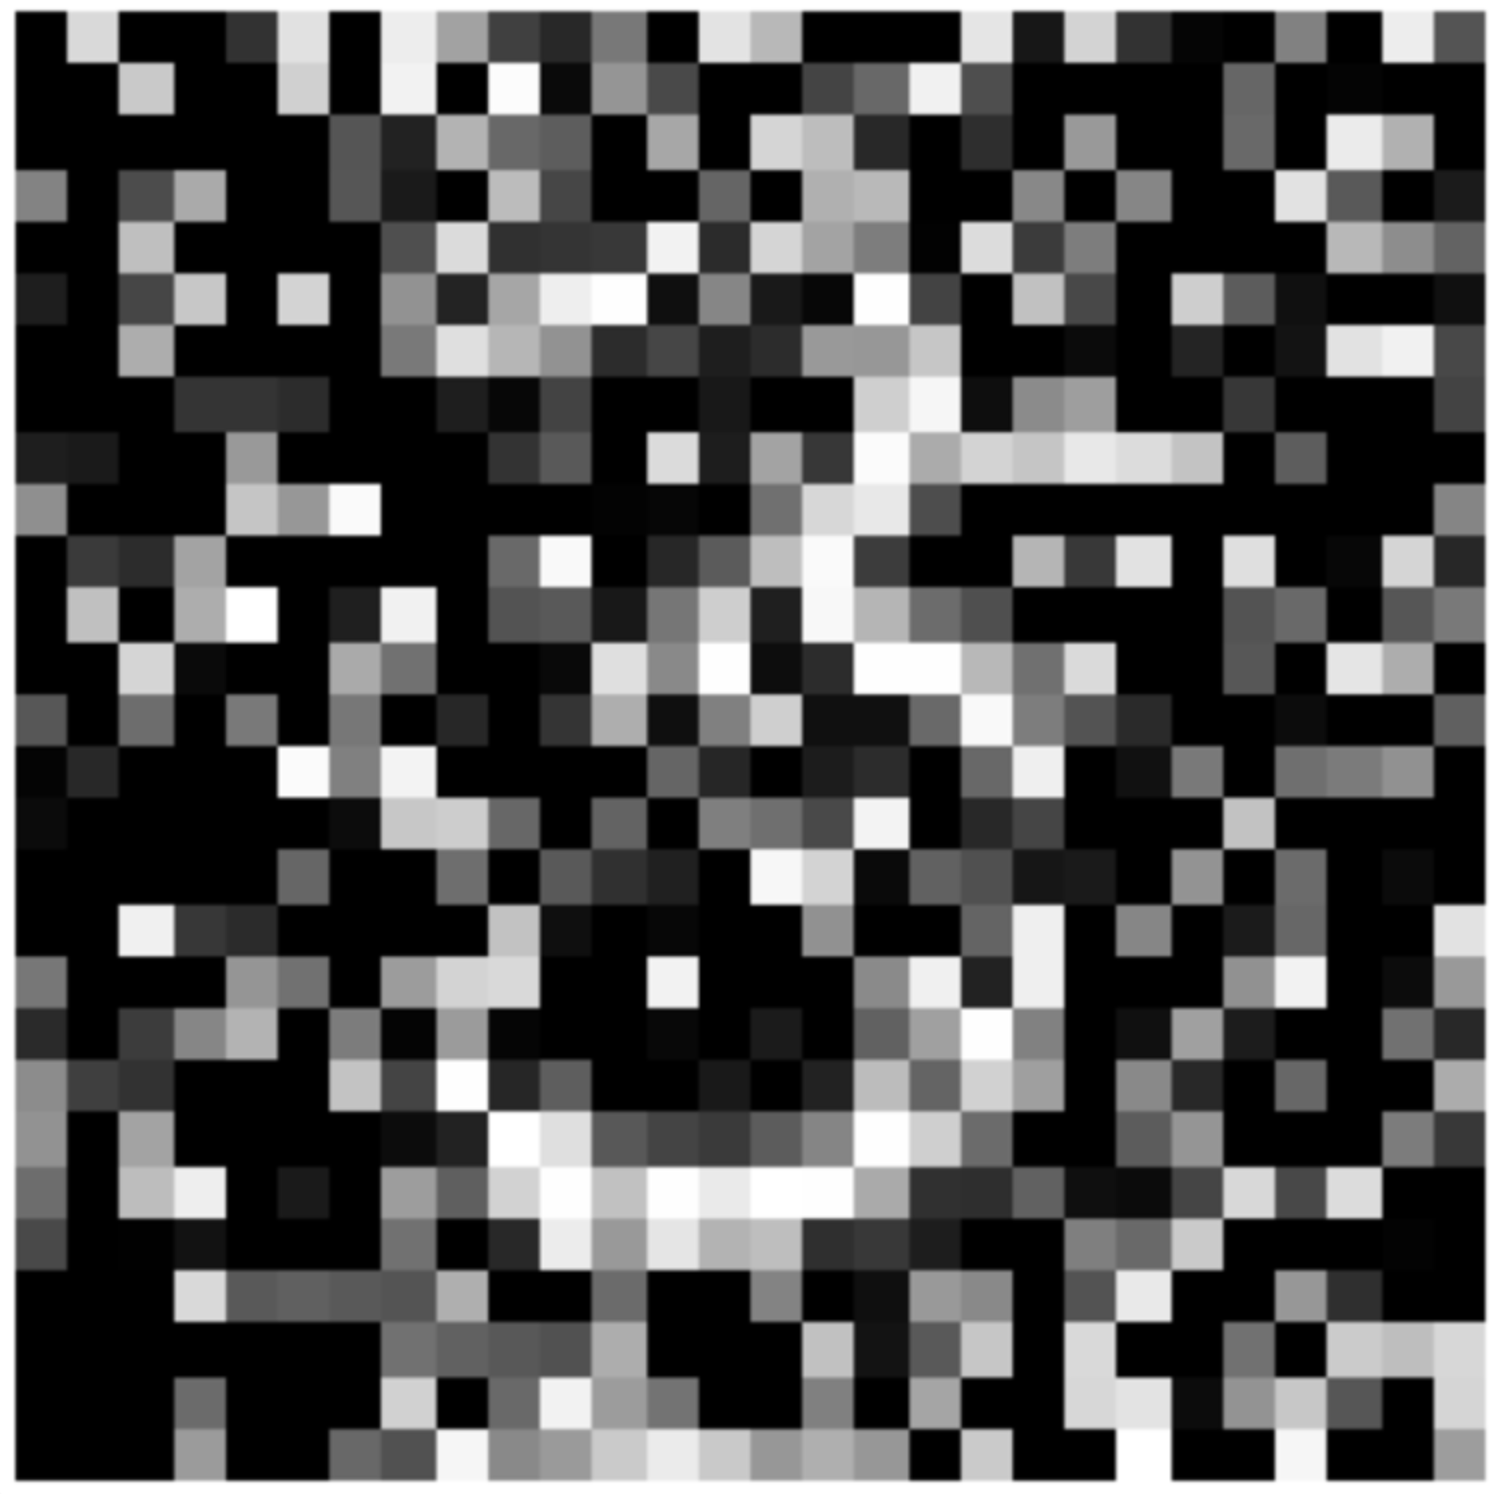

**Part c)** Train an ANN model as we did in Lecture 08.ipynb, but use early stopping. At what value did the accuracy fall? Explain why accuracy is lower in noisy MNIST when compared to the model trained in class on non-noisy, original MNIST data (its accuracy was 96%).

**Part d)** Now add ridge regression to the the dense layer of the model defined in Part c) to improve the model performance. You should be getting accuracy better than that in Part c). Explain why did ridge regression improved, if it did, the model.





In [ ]:
# part a

In [45]:
def random_sel_replacement(image):
    # Flatten the image to a 1D tensor
    flat_image = image.view(-1)
    
    # Randomly select pixels to modify
    num_pixels = flat_image.size(0)
    num_to_modify = int(0.5 * num_pixels)
    indices_to_modify = torch.randperm(num_pixels)[:num_to_modify]
    modified_image = flat_image.clone()
    modified_image[indices_to_modify] = torch.randint(0, 256, (num_to_modify,)).float() / 255.0  # Replace selected pixels with random values between 0 and 255 and normalize to [0, 1]
    return modified_image.view(1, 28, 28)  # Reshape back to original image dimensions



transform = transforms.Compose([
    transforms.ToTensor(), # Convert PIL Image to PyTorch tensor
    random_sel_replacement, # random select pixels and replace them with random values before normalization
    transforms.Normalize((0.1307,), (0.3081,)) # Normalize with mean and standard deviation
])

train_dataset_2 = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_2 = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
val_dataset_2, test_dataset_2 = torch.utils.data.random_split(test_dataset_2, [5000, 5000], generator=torch.Generator().manual_seed(3407))

# Create data loaders for training, validation, and testing
train_loader_2 = DataLoader(train_dataset_2, batch_size=64, shuffle=True)
val_loader_2 = DataLoader(val_dataset_2, batch_size=64, shuffle=False)
test_loader_2 = DataLoader(test_dataset_2, batch_size=64, shuffle=False)

In [ ]:
# part b

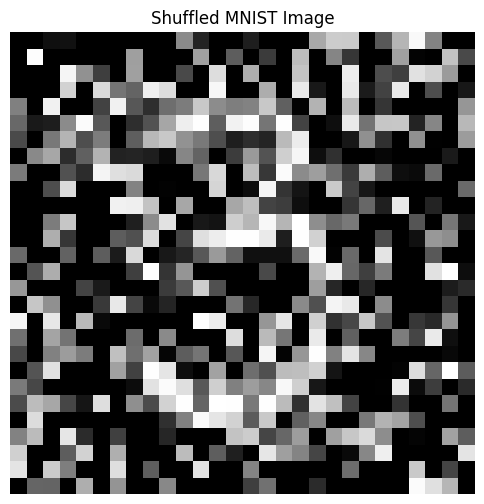

In [46]:
image = train_dataset_2[50][0]  # Get the first image from the original dataset (before shuffling)
MNISTplot2D(image)

In [ ]:
# part c

In [68]:
model2 = MnistClassifier().to(device)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.SGD(model2.parameters(), lr=0.01, momentum=0.9, nesterov=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, patience=5, factor=0.5)  # Reduce learning rate on plateau

In [69]:
train_losses, val_losses, best_val_loss, best_model, last_improvement_epoch = train_model(model2, train_loader_2, val_loader_2, optimizer2, criterion2,scheduler, num_epochs=1000)

Epoch 1/1000, Train Loss: 0.7988, Validation Loss: 0.5382
Epoch 2/1000, Train Loss: 0.5189, Validation Loss: 0.4616
Epoch 3/1000, Train Loss: 0.4531, Validation Loss: 0.4023
Epoch 4/1000, Train Loss: 0.4206, Validation Loss: 0.3968
Epoch 5/1000, Train Loss: 0.3976, Validation Loss: 0.3488
Epoch 6/1000, Train Loss: 0.3897, Validation Loss: 0.3665
Epoch 7/1000, Train Loss: 0.3760, Validation Loss: 0.3593
Epoch 8/1000, Train Loss: 0.3654, Validation Loss: 0.3372
Epoch 9/1000, Train Loss: 0.3650, Validation Loss: 0.3270
Epoch 10/1000, Train Loss: 0.3548, Validation Loss: 0.3307
Epoch 11/1000, Train Loss: 0.3560, Validation Loss: 0.3423
Epoch 12/1000, Train Loss: 0.3532, Validation Loss: 0.3366
Epoch 13/1000, Train Loss: 0.3457, Validation Loss: 0.3385
Epoch 14/1000, Train Loss: 0.3492, Validation Loss: 0.3371
Epoch 15/1000, Train Loss: 0.3482, Validation Loss: 0.3378
Epoch 16/1000, Train Loss: 0.3204, Validation Loss: 0.3049
Epoch 17/1000, Train Loss: 0.3141, Validation Loss: 0.2982
Epoch 

In [71]:
# print final lr
final_lr = optimizer2.param_groups[0]['lr']
print(f"Final Learning Rate: {final_lr:.6f}")

Final Learning Rate: 0.000156


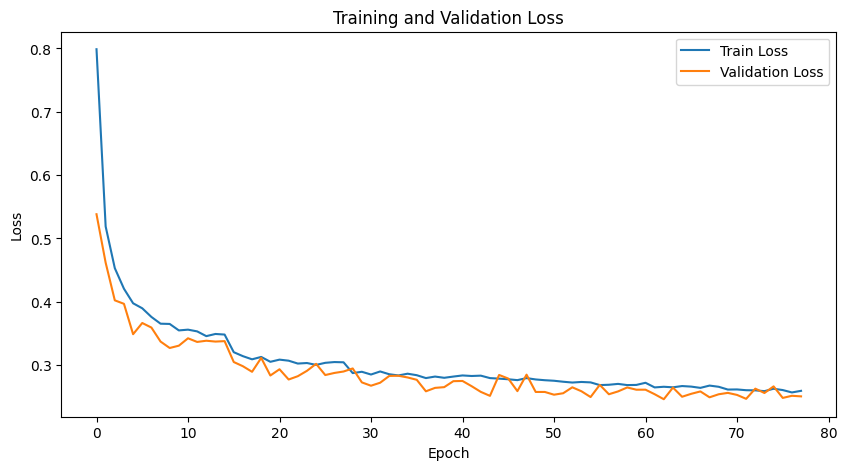

In [70]:
# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [73]:
model2_test = MnistClassifier().to(device)
model2_test.load_state_dict(best_model)
model2_test.eval()


@torch.no_grad()
def evaluate_model(model, test_loader, criterion):
    test_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        test_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    accuracy = correct / total
    return avg_test_loss, accuracy

test_loss, test_accuracy = evaluate_model(model2_test, test_loader_2, criterion)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2791, Test Accuracy: 0.9058


In [ ]:
# Part d

In [74]:
model3 = MnistClassifier().to(device)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.SGD(model3.parameters(), lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4)  # Add L2 regularization
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, patience=5, factor=0.5)  # Reduce learning rate on plateau

In [75]:
train_losses_3, val_losses_3, best_val_loss_3, best_model_3, last_improvement_epoch_3 = train_model(model3, train_loader_2, val_loader_2, optimizer2, criterion2,scheduler, num_epochs=1000)

Epoch 1/1000, Train Loss: 0.8000, Validation Loss: 0.5469
Epoch 2/1000, Train Loss: 0.5282, Validation Loss: 0.4494
Epoch 3/1000, Train Loss: 0.4627, Validation Loss: 0.4004
Epoch 4/1000, Train Loss: 0.4269, Validation Loss: 0.3870
Epoch 5/1000, Train Loss: 0.4082, Validation Loss: 0.3563
Epoch 6/1000, Train Loss: 0.3922, Validation Loss: 0.3944
Epoch 7/1000, Train Loss: 0.3816, Validation Loss: 0.3655
Epoch 8/1000, Train Loss: 0.3770, Validation Loss: 0.3623
Epoch 9/1000, Train Loss: 0.3676, Validation Loss: 0.3737
Epoch 10/1000, Train Loss: 0.3575, Validation Loss: 0.3522
Epoch 11/1000, Train Loss: 0.3595, Validation Loss: 0.3498
Epoch 12/1000, Train Loss: 0.3533, Validation Loss: 0.3423
Epoch 13/1000, Train Loss: 0.3479, Validation Loss: 0.3198
Epoch 14/1000, Train Loss: 0.3443, Validation Loss: 0.3200
Epoch 15/1000, Train Loss: 0.3405, Validation Loss: 0.3147
Epoch 16/1000, Train Loss: 0.3423, Validation Loss: 0.3400
Epoch 17/1000, Train Loss: 0.3415, Validation Loss: 0.3359
Epoch 

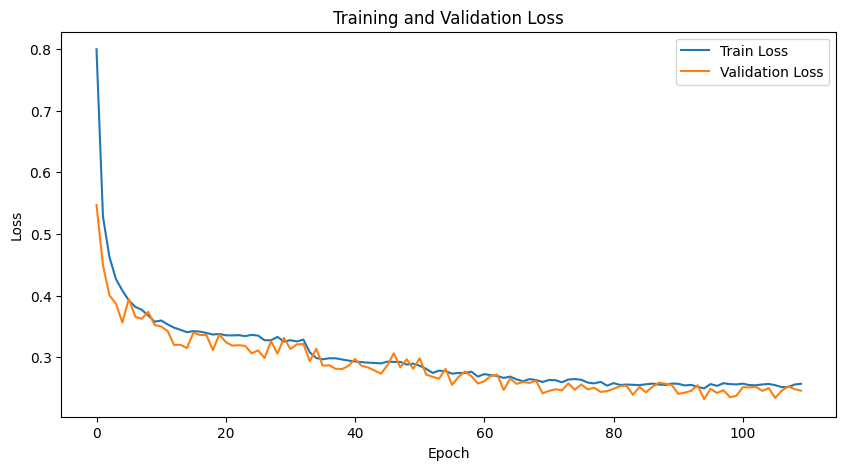

In [77]:
# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses_3, label='Train Loss')
plt.plot(val_losses_3, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [76]:

model3_test = MnistClassifier().to(device)
model3_test.load_state_dict(best_model_3)
model3_test.eval()


@torch.no_grad()
def evaluate_model(model, test_loader, criterion):
    test_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        test_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    accuracy = correct / total
    return avg_test_loss, accuracy

test_loss, test_accuracy = evaluate_model(model3_test, test_loader_2, criterion2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2537, Test Accuracy: 0.9172
